# 01 - Broken Model: forcing a non-linear model to fail

## Aim

This notebook intentionally forces a non-linear model to fail. The model is restricted to calendar and acquisition proxies rather than behavioral intent variables. The objective is not to build the best classifier; it is to create a reproducible deployment-like failure that can be measured, localized, and later explained causally.

Research-grade claim to test: **random validation leaks seasonal regimes across train and test, making a shortcut model look more reliable than it is under temporal deployment.**


In [2]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import *
from src.preprocessing import load_online_shoppers, random_reference_split, temporal_split, adjacent_temporal_split
from src.training import fit_predict, make_pipeline
from src.evaluation import (
    metric_row, confusion, subgroup_metrics, summarize_runs, evidence_table,
    paired_bootstrap_delta, quantitative_claims
)
from src.visualization import (
    plot_confusion, plot_subgroup, plot_metric_comparison, plot_calibration,
    plot_evidence_table, plot_drift_scores, plot_permutation_importance, plot_learning_curve
)
from src.experiments import (
    run_reference_and_failure, run_controlled_causal_test, run_corrected_protocol,
    run_seed_variance, permutation_importance_table, drift_table, write_metrics,
    feature_perturbation_test, negative_control_representation_test
)

pd.set_option('display.max_columns', 80)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)


## Dataset, base rates, and seasonal regimes

The positive class is purchase. Because purchases are rare, accuracy alone is not a valid symptom metric. We therefore track PR-AUC, recall, balanced accuracy, Brier score, and expected calibration error.


In [3]:
df = load_online_shoppers()
print(f'Shape: {df.shape[0]:,} sessions x {df.shape[1]} columns')
print(f'Purchase prevalence: {df[TARGET].mean():.3f}')
month_rates = pd.crosstab(df['Month'], df[TARGET], normalize='index').rename(columns={0:'no_purchase',1:'purchase'})
display(month_rates.sort_index().round(3))


Shape: 12,330 sessions x 19 columns
Purchase prevalence: 0.155


Revenue,no_purchase,purchase
Month,,
Aug,0.824,0.176
Dec,0.875,0.125
Feb,0.984,0.016
Jul,0.847,0.153
June,0.899,0.101
Mar,0.899,0.101
May,0.891,0.109
Nov,0.746,0.254
Oct,0.791,0.209


## Experimental design: reference versus forced failure

Two evaluations are compared.

- **Reference:** random split, where seasonal regimes are mixed across train and test.
- **Forced failure:** train on sessions up to September and deploy on October-December.

The model family is held fixed. The failure is induced by changing the evaluation regime and restricting the model to shortcut-like variables.


In [4]:
random_broken, temporal_broken = run_reference_and_failure(df, seed=RANDOM_SEED)
metrics = pd.DataFrame([
    metric_row(random_broken['name'], random_broken['y_test'], random_broken['proba'], random_broken['threshold']),
    metric_row(temporal_broken['name'], temporal_broken['y_test'], temporal_broken['proba'], temporal_broken['threshold']),
])
display(metrics.round(4))
write_metrics('table01_reference_vs_temporal.csv', metrics)


,model,n,prevalence,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,brier,ece
0,broken_random_split,2466,0.1549,0.1525,0.6407,0.6068,0.2290,0.5576,0.3247,0.6641,0.2492,0.1257,0.0053
1,broken_temporal_deployment,5274,0.2069,0.1230,0.5633,0.5645,0.2525,0.5665,0.3493,0.5852,0.2544,0.1679,0.0755


WindowsPath('C:/Users/hp/Desktop/Project/ml-failure-online-shoppers/outputs/metrics/table01_reference_vs_temporal.csv')

## Quantitative symptom statements

This cell converts metrics into report-ready sentences. These phrases make the failure explicit: they quantify the PR-AUC drop, recall degradation, and calibration damage instead of leaving the reader to infer them from tables.


In [5]:
random_metrics = metric_row(random_broken['name'], random_broken['y_test'], random_broken['proba'], random_broken['threshold'])
temporal_metrics = metric_row(temporal_broken['name'], temporal_broken['y_test'], temporal_broken['proba'], temporal_broken['threshold'])
claim_rows = []
for metric, label in [('pr_auc', 'PR-AUC'), ('recall', 'purchase recall'), ('balanced_accuracy', 'balanced accuracy'), ('ece', 'expected calibration error')]:
    direction = temporal_metrics[metric] - random_metrics[metric]
    claim_rows.append({
        'claim': f'{label} changed from {random_metrics[metric]:.3f} under random validation to {temporal_metrics[metric]:.3f} under temporal deployment (delta {direction:+.3f}).'
    })
claims = pd.DataFrame(claim_rows)
display(claims)
write_metrics('table02_failure_claims.csv', claims)


,claim
0,PR-AUC changed from 0.249 under random validat...
1,purchase recall changed from 0.558 under rando...
2,balanced accuracy changed from 0.607 under ran...
3,expected calibration error changed from 0.005 ...


WindowsPath('C:/Users/hp/Desktop/Project/ml-failure-online-shoppers/outputs/metrics/table02_failure_claims.csv')

## Failure Evidence Table with bootstrap confidence intervals

A single table summarizes the symptom with uncertainty. Bootstrap intervals are useful because the assignment explicitly asks whether observed differences may be random rather than structural.


,model,metric,estimate,ci_low,ci_high,threshold,n,n_boot
0,broken_random_split,pr_auc,0.2492,0.2205,0.2938,0.1525,2466,500
1,broken_random_split,recall,0.5576,0.5063,0.6068,0.1525,2466,500
2,broken_random_split,balanced_accuracy,0.6068,0.5801,0.6348,0.1525,2466,500
3,broken_random_split,ece,0.0053,0.0036,0.0223,0.1525,2466,500
4,broken_random_split,brier,0.1257,0.1172,0.1344,0.1525,2466,500
5,broken_temporal_deployment,pr_auc,0.2544,0.2373,0.2748,0.1230,5274,500
6,broken_temporal_deployment,recall,0.5665,0.5403,0.5968,0.1230,5274,500
7,broken_temporal_deployment,balanced_accuracy,0.5645,0.5508,0.5817,0.1230,5274,500
8,broken_temporal_deployment,ece,0.0755,0.0655,0.0856,0.1230,5274,500
9,broken_temporal_deployment,brier,0.1679,0.1609,0.1748,0.1230,5274,500


WindowsPath('C:/Users/hp/Desktop/Project/ml-failure-online-shoppers/outputs/metrics/table03_initial_failure_bootstrap_ci.csv')

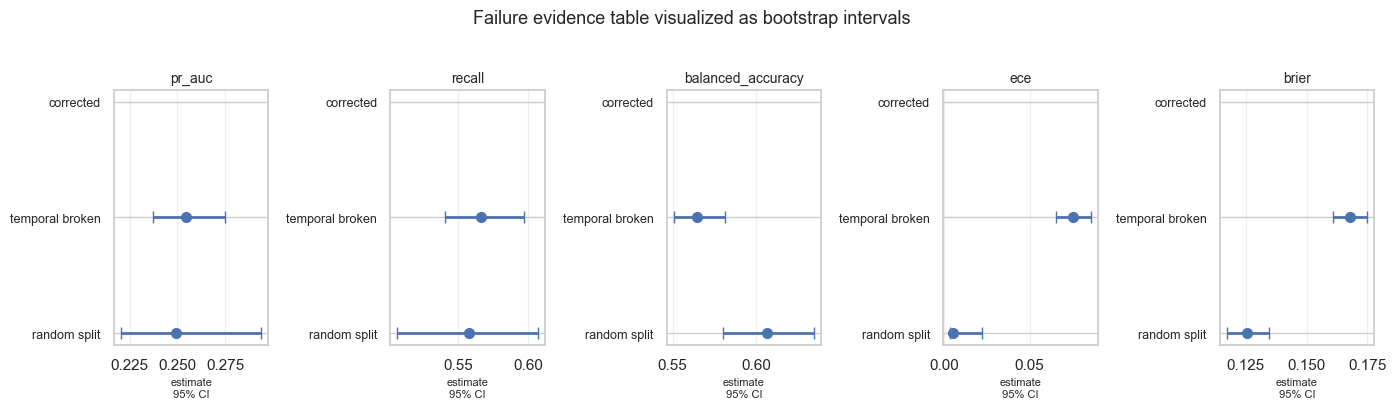

In [6]:
evidence = evidence_table([random_broken, temporal_broken], n_boot=500)
display(evidence.round(4))
plot_evidence_table(evidence, 'fig02_initial_failure_bootstrap_ci.svg')
write_metrics('table03_initial_failure_bootstrap_ci.csv', evidence)


## Confusion matrices: visible failure, not only scalar metrics

The confusion matrices show how purchase sessions are handled under both evaluation regimes.


,pred_no_purchase,pred_purchase
actual_no_purchase,1367,717
actual_purchase,169,213


,pred_no_purchase,pred_purchase
actual_no_purchase,2353,1830
actual_purchase,473,618


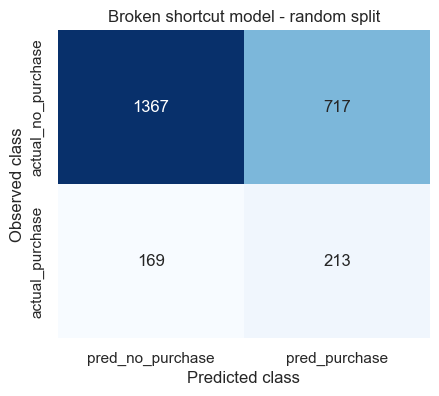

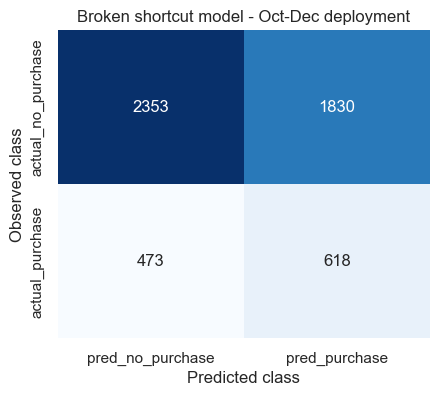

In [7]:
fig1, cm_random = plot_confusion(random_broken['y_test'], random_broken['proba'], random_broken['threshold'], 'Broken shortcut model - random split', 'fig01a_confusion_random_broken.svg')
fig2, cm_temporal = plot_confusion(temporal_broken['y_test'], temporal_broken['proba'], temporal_broken['threshold'], 'Broken shortcut model - Oct-Dec deployment', 'fig01b_confusion_temporal_broken.svg')
display(cm_random)
display(cm_temporal)


## Subgroup collapse by deployment month

A strong failure mode should be localized, not merely averaged. If the model learned a temporal shortcut, the damage should be visible in late-year subgroups.


,model,group,n,prevalence,recall,precision,f1,balanced_accuracy,roc_auc,pr_auc
0,broken_temporal,Dec,1727,0.1251,0.6667,0.1716,0.2730,0.6034,0.6432,0.2061
1,broken_temporal,Nov,2998,0.2535,0.5474,0.3054,0.3921,0.5623,0.5825,0.3028
2,broken_temporal,Oct,549,0.2095,0.5043,0.2348,0.3204,0.5344,0.5532,0.2278


WindowsPath('C:/Users/hp/Desktop/Project/ml-failure-online-shoppers/outputs/metrics/table03_month_subgroup_broken.csv')

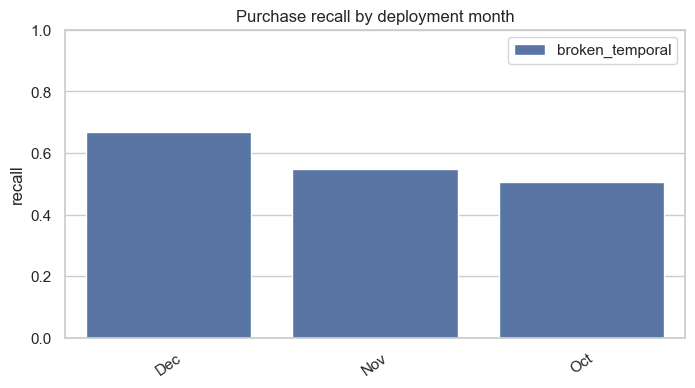

In [8]:
month_perf = subgroup_metrics(temporal_broken['test_frame'], temporal_broken['proba'], temporal_broken['threshold'], 'Month', 'broken_temporal')
display(month_perf.round(4))
plot_subgroup(month_perf, 'recall', 'Purchase recall by deployment month', 'fig06a_recall_by_month_broken.svg')
write_metrics('table03_month_subgroup_broken.csv', month_perf)


## Bonus symptom preview: imbalance hides the error

This is the second failure mode developed later. At threshold 0.50, the model can retain superficially acceptable accuracy while missing many purchases.


In [9]:
imbalance_preview = pd.DataFrame([
    metric_row('broken_temporal_threshold_0_50', temporal_broken['y_test'], temporal_broken['proba'], 0.50),
    metric_row('broken_temporal_tuned_threshold', temporal_broken['y_test'], temporal_broken['proba'], temporal_broken['threshold']),
])
display(imbalance_preview.round(4))
write_metrics('table12a_imbalance_preview.csv', imbalance_preview)


,model,n,prevalence,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,brier,ece
0,broken_temporal_threshold_0_50,5274,0.2069,0.500,0.7931,0.5000,0.0000,0.0000,0.0000,0.5852,0.2544,0.1679,0.0755
1,broken_temporal_tuned_threshold,5274,0.2069,0.123,0.5633,0.5645,0.2525,0.5665,0.3493,0.5852,0.2544,0.1679,0.0755


WindowsPath('C:/Users/hp/Desktop/Project/ml-failure-online-shoppers/outputs/metrics/table12a_imbalance_preview.csv')

## Conclusion of Notebook 01

The model was intentionally forced to fail under a deployment-like temporal shift. The symptom is visible through scalar metrics, bootstrap intervals, confusion matrices, and subgroup recall. Notebook 02 tests whether the cause is shortcut reliance rather than generic model weakness.
